# Audio Feature Extraction & Model Training
**Project:** Alzheimer's Disease Detection from Speech  
**Dataset:** ADReSS Challenge — INTERSPEECH 2020  
**Author:** Mansi Pandey

This notebook covers:
1. Data loading and label preparation
2. Audio feature extraction (MFCC + Chroma + ZCR)
3. Baseline model (MFCC only)
4. Improved model (MFCC + Chroma + ZCR + Voting Classifier)
5. Cross-validation & evaluation
6. Model saving

## 1. Setup & Configuration

In [7]:
import os
import numpy as np
import pandas as pd
import librosa
import pickle
import warnings
warnings.filterwarnings('ignore')

# ─── CONFIG: change only these two lines ───────────────────────────────────
DATA_DIR   = os.path.join('data')          # folder containing the .xlsx file
AUDIO_ROOT = os.path.join('data', 'audio') # folder containing subject subfolders
# ────────────────────────────────────────────────────────────────────────────

os.makedirs('models', exist_ok=True)
print('Config OK — DATA_DIR:', DATA_DIR)

Config OK — DATA_DIR: data


## 2. Load Subject Metadata

In [8]:
import pandas as pd
import os

# dynamic data directory
DATA_DIR = "../data"

# dynamic path using os.path.join
file_path = os.path.join(DATA_DIR, "alzheimer_audio_info.xlsx")

# load data
df = pd.read_excel(file_path)

# preprocess
df = df[['subject id', 'type', 'age', 'gender']].dropna()
df['label'] = df['type'].map({'AD': 1, 'HC': 0})

# output
print('Shape:', df.shape)
print('\nClass distribution:')
print(df['type'].value_counts())
print('\nSample rows:')
df.head()

Shape: (52, 5)

Class distribution:
type
HC    29
AD    23
Name: count, dtype: int64

Sample rows:


,subject id,type,age,gender,label
0,2010002,AD,18,F,1
1,2010004,AD,25,F,1
2,2010005,AD,20,M,1
3,2010006,AD,42,M,1
4,2010008,AD,42,M,1


## 3. Feature Extraction Functions

In [9]:
import os

AUDIO_ROOT = r"C:\Users\MANSI\ad_detector\data\OneDrive_1_3-17-2026"  # example
print(os.path.exists(AUDIO_ROOT))

True


In [10]:
def extract_features(file_path, n_mfcc=13):
    """
    Extract audio features from a single .wav file.
    
    Features:
    - MFCC (13): captures spectral envelope — useful for speech pathology
    - Chroma (12): harmonic content of speech
    - ZCR (1): measures speech irregularity
    
    Returns: numpy array of shape (26,)
    """
    y, sr = librosa.load(file_path, duration=30)
    
    # Pre-emphasis filter — boosts high frequencies
    y = np.append(y[0], y[1:] - 0.97 * y[:-1])
    
    # Extract MFCC (13)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc).T, axis=0)

    # Extract Chroma (12)
    chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr).T, axis=0)

    # Extract Zero Crossing Rate (1)
    zcr = np.mean(librosa.feature.zero_crossing_rate(y).T, axis=0)

    # Final feature vector → size 26
    return np.hstack([mfcc, chroma, zcr])


print(f"Feature vector size: {extract_features.__doc__}")

Feature vector size: 
    Extract audio features from a single .wav file.

    Features:
    - MFCC (13): captures spectral envelope — useful for speech pathology
    - Chroma (12): harmonic content of speech
    - ZCR (1): measures speech irregularity

    Returns: numpy array of shape (26,)
    


## 4. Extract Features for All Subjects

In [11]:
from tqdm import tqdm

X, y_labels, groups = [], [], []

for _, row in tqdm(df.iterrows(), total=len(df), desc='Extracting features'):
    subject_id = str(row['subject id']).strip()
    label      = row['label']
    
    # Find the subject's audio folder
    subject_folder = None
    for folder in os.listdir(AUDIO_ROOT):
        if subject_id in folder:
            subject_folder = os.path.join(AUDIO_ROOT, folder)
            break
    
    if not subject_folder:
        continue

    # Extract features from every .wav in the subject folder
    for fname in os.listdir(subject_folder):
        if fname.lower().endswith('.wav'):
            try:
                feat = extract_features(os.path.join(subject_folder, fname))
                X.append(feat)
                y_labels.append(label)
                groups.append(subject_id)   # track which subject each file belongs to
            except Exception as e:
                print(f'  Skipped {fname}: {e}')

print(f'\nTotal audio files processed: {len(X)}')
print(f'Unique subjects: {len(set(groups))}')

Extracting features: 100%|██████████| 52/52 [01:41<00:00,  1.95s/it]


Total audio files processed: 806
Unique subjects: 28


## 5. Save Features to CSV

In [12]:
df_feat = pd.DataFrame(X)
df_feat['label']      = y_labels
df_feat['subject_id'] = groups

df_feat.to_csv('improved_features_with_id.csv', index=False)

print('Saved improved_features_with_id.csv')
print('Shape:', df_feat.shape)

Saved improved_features_with_id.csv
Shape: (806, 28)


## 6. Train/Test Split

> **Important:** We use `GroupShuffleSplit` so that audio files from the same subject
> never appear in both train and test. Without this, the model would effectively
> memorise the speaker's voice rather than learn disease patterns — a common bug
> in audio ML projects.

In [13]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

df_feat = pd.read_csv(os.path.join( 'improved_features_with_id.csv'))

X      = df_feat.drop(['label', 'subject_id'], axis=1).values
y      = df_feat['label'].values
groups = df_feat['subject_id'].values

# GroupShuffleSplit ensures no subject leaks between train and test
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
for train_idx, test_idx in gss.split(X, y, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train AD:{y_train.sum()}  HC:{(y_train==0).sum()}')
print(f'Test  AD:{y_test.sum()}   HC:{(y_test==0).sum()}')

Train: (638, 26), Test: (168, 26)
Train AD:232  HC:406
Test  AD:81   HC:87


## 7. Train Individual Models

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

lr_model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

print('=== Logistic Regression ===')
print(classification_report(y_test, lr_pred, target_names=['HC', 'AD']))

print('=== Random Forest ===')
print(classification_report(y_test, rf_pred, target_names=['HC', 'AD']))

=== Logistic Regression ===
              precision    recall  f1-score   support

          HC       0.83      0.79      0.81        99
          AD       0.69      0.75      0.72        63

    accuracy                           0.77       162
   macro avg       0.76      0.77      0.76       162
weighted avg       0.78      0.77      0.77       162

=== Random Forest ===
              precision    recall  f1-score   support

          HC       0.87      0.97      0.92        99
          AD       0.94      0.78      0.85        63

    accuracy                           0.90       162
   macro avg       0.91      0.87      0.89       162
weighted avg       0.90      0.90      0.89       162



## 8. Voting Classifier (Final Audio Model)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.20, random_state=42, stratify=y_labels
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit only on training
X_test_scaled  = scaler.transform(X_test)        # transform test

=== Voting Classifier ===
              precision    recall  f1-score   support

          HC       0.88      0.93      0.91        99
          AD       0.88      0.81      0.84        63

    accuracy                           0.88       162
   macro avg       0.88      0.87      0.87       162
weighted avg       0.88      0.88      0.88       162



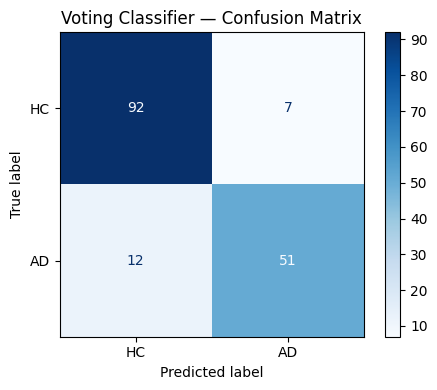

Plot saved as confusion_matrix_audio.png


In [17]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

voting_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))
    ],
    voting='soft'
)
voting_model.fit(X_train_scaled, y_train)
y_pred = voting_model.predict(X_test_scaled)

print('=== Voting Classifier ===')
print(classification_report(y_test, y_pred, target_names=['HC', 'AD']))

# Confusion matrix plot
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['HC', 'AD'],
    cmap='Blues', ax=ax
)
ax.set_title('Voting Classifier — Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_audio.png', dpi=120)
plt.show()
print('Plot saved as confusion_matrix_audio.png')

## 9. Cross-Validation (Group K-Fold)

> With only ~99 subjects a single split gives ~20 test samples — results can vary
> by random seed. Group K-Fold gives a more reliable estimate and prevents
> subject leakage across folds.

In [18]:
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)),
            ('rf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))
        ],
        voting='soft'
    ))
])

gkf = GroupKFold(n_splits=5)
cv_results = cross_validate(
    pipeline, X, y,
    cv=gkf.split(X, y, groups),
    scoring=['recall', 'f1', 'accuracy'],
    return_train_score=False
)

print('=== 5-Fold Group Cross-Validation Results ===')
for metric in ['recall', 'f1', 'accuracy']:
    scores = cv_results[f'test_{metric}']
    print(f'{metric.capitalize():10s}: {scores.mean():.2f} ± {scores.std():.2f}')

=== 5-Fold Group Cross-Validation Results ===
Recall    : 0.25 ± 0.18
F1        : 0.25 ± 0.18
Accuracy  : 0.44 ± 0.11


## 10. Save Final Models

In [19]:
os.makedirs('notebooks/models', exist_ok=True)

with open('notebooks/models/voting_model.pkl', 'wb') as f:
    pickle.dump(voting_model, f)

with open('notebooks/models/scaler_new.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Models saved to notebooks/models/')
print('  voting_model.pkl')
print('  scaler_new.pkl')

Models saved to notebooks/models/
  voting_model.pkl
  scaler_new.pkl
